# Sample selection 

In [1]:
import pandas as pd
import subsetmask as sm
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# %% setting paths
MAIN_DIR_NAME = "proseg_slides_meta"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

In [4]:
# setting paths
slide_name = 'SLIDE04'
meta_path = MAIN_DIR / f'{slide_name}_meta.tsv'

In [7]:
# run this to activate qt
%gui qt

## Slide 4

In [5]:
meta = pd.read_csv(meta_path, sep='\t', index_col=0)

# remove column sample_name if it was already added
if 'sample_name' in meta.columns:
    meta = meta.drop(columns=['sample_name'])

# check columns
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale
0,0,c_4_148_1200,389.99450,2561.8610,0.578297,6,45.50,296.0,1.0
1,1,c_4_160_1453,929.81506,2048.5745,0.621575,6,18.25,186.0,1.0
2,2,c_4_160_1452,937.05630,2050.9023,0.365066,4,37.75,244.0,1.0
3,3,c_4_160_1451,1022.33000,2049.8896,0.447500,7,25.00,206.0,1.0
4,4,c_4_160_1324,726.74194,2110.9038,0.526499,7,116.75,474.0,1.0


In [6]:
# add slide_ID column
meta['slide_ID'] = str(slide_name)

# add a cell_id column with slide_name + cell
meta['cell_id'] =  meta['slide_ID'] + '_' + meta['cell'].astype(str)
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id
0,0,c_4_148_1200,389.99450,2561.8610,0.578297,6,45.50,296.0,1.0,SLIDE04,SLIDE04_0
1,1,c_4_160_1453,929.81506,2048.5745,0.621575,6,18.25,186.0,1.0,SLIDE04,SLIDE04_1
2,2,c_4_160_1452,937.05630,2050.9023,0.365066,4,37.75,244.0,1.0,SLIDE04,SLIDE04_2
3,3,c_4_160_1451,1022.33000,2049.8896,0.447500,7,25.00,206.0,1.0,SLIDE04,SLIDE04_3
4,4,c_4_160_1324,726.74194,2110.9038,0.526499,7,116.75,474.0,1.0,SLIDE04,SLIDE04_4


In [8]:
# create the image for slide1
slide = sm.Image(metadata_df=meta, 
                  images_col='slide_ID',
                  image_name=slide_name,
                  x_col = 'centroid_x',
                  y_col = 'centroid_y',)

# add store image method
slide.store_image(group_col=None, 
                   figsize=(30,50),
                   dpi=300, 
                   dot_size=2,
                   cmap='tab20')

/Users/robin.carvajal/miniforge3/envs/subsetmask/lib/python3.10/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (135000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [9]:
# launches napari with the generated image, ready for selection
slide.draw_labels()

<Labels layer 'Mask' at 0x35f3f59f0>

In [10]:
# without closing napari we run this line to save the annotations
slide.save_annotations(ann_col_name="sample_name")

# we change our annotations for something more meaningful
map = {
    "label_1": "CTRL03",
    "label_2": "CTRL04",
    "label_3": "CTRL05",
    "label_4": "PWCF06",
}

slide.rename_annotations(ann_col_name="sample_name", mapping_dict=map)

# we extract the annotated df from the object
annotated_meta_slide = slide.annotated_metadata_df

# check the annotated metadata
annotated_meta_slide.head()


,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_4_148_1200,389.99450,2561.8610,0.578297,6,45.50,296.0,1.0,SLIDE04,SLIDE04_0,PWCF06
1,1,c_4_160_1453,929.81506,2048.5745,0.621575,6,18.25,186.0,1.0,SLIDE04,SLIDE04_1,PWCF06
2,2,c_4_160_1452,937.05630,2050.9023,0.365066,4,37.75,244.0,1.0,SLIDE04,SLIDE04_2,PWCF06
3,3,c_4_160_1451,1022.33000,2049.8896,0.447500,7,25.00,206.0,1.0,SLIDE04,SLIDE04_3,PWCF06
4,4,c_4_160_1324,726.74194,2110.9038,0.526499,7,116.75,474.0,1.0,SLIDE04,SLIDE04_4,PWCF06


check

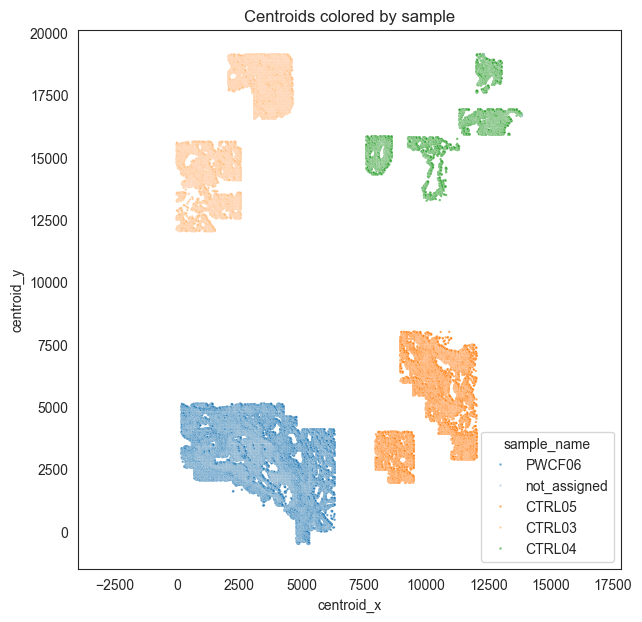

In [11]:
# scater plot using matplot lib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
sns.set_style("white")
sns.scatterplot(
    data=annotated_meta_slide,
    x="centroid_x",
    y="centroid_y",
    hue="sample_name",        # or "library_id", etc.
    s=3,
    alpha=0.7,
    palette="tab20"      # or any seaborn/matplotlib palette
)
plt.axis("equal")
plt.title("Centroids colored by sample")
plt.show()

In [12]:
annotated_meta_slide.groupby(["slide_ID", "sample_name"]).size().reset_index(name="count")

,slide_ID,sample_name,count
0,SLIDE04,CTRL03,52937
1,SLIDE04,CTRL04,18383
2,SLIDE04,CTRL05,31078
3,SLIDE04,PWCF06,95589
4,SLIDE04,not_assigned,6


## save the annotated metadata

In [14]:
# Save the annotated metadata
annotated_meta_slide.to_csv(meta_path, index=False)

In [15]:
# check if the saved file is correct
meta = pd.read_csv(meta_path)
meta

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_4_148_1200,389.99450,2561.8610,0.578297,6,45.50,296.0,1.0,SLIDE04,SLIDE04_0,PWCF06
1,1,c_4_160_1453,929.81506,2048.5745,0.621575,6,18.25,186.0,1.0,SLIDE04,SLIDE04_1,PWCF06
2,2,c_4_160_1452,937.05630,2050.9023,0.365066,4,37.75,244.0,1.0,SLIDE04,SLIDE04_2,PWCF06
3,3,c_4_160_1451,1022.33000,2049.8896,0.447500,7,25.00,206.0,1.0,SLIDE04,SLIDE04_3,PWCF06
4,4,c_4_160_1324,726.74194,2110.9038,0.526499,7,116.75,474.0,1.0,SLIDE04,SLIDE04_4,PWCF06
...,...,...,...,...,...,...,...,...,...,...,...,...
197988,197988,c_4_22_185,12425.67000,18949.6230,0.524038,4,78.00,398.0,1.0,SLIDE04,SLIDE04_197988,CTRL04
197989,197989,c_4_22_176,12419.64200,18955.5900,0.435811,7,37.00,264.0,1.0,SLIDE04,SLIDE04_197989,CTRL04
197990,197990,c_4_22_174,12424.49100,18958.0060,0.452991,1,58.50,308.0,1.0,SLIDE04,SLIDE04_197990,CTRL04
197991,197991,c_4_22_183,12430.70600,18951.0570,0.513587,1,46.00,274.0,1.0,SLIDE04,SLIDE04_197991,CTRL04
